# Deep Learning

<hr>

<center>
<div>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/mgmt_474_ai_logo_02-modified.png" width="200"/>
</div>
</center>

# <center><a class="tocSkip"></center>
# <center>QM47400 Predictive Analytics</center>
# <center>Professor: Davi Moreira </center>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/blob/main/notebooks/nb19_deep_learning_student.ipynb)

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain in plain language **what deep learning is**.
2. Build the right **intuition** for what a neural network is and how it learns.
3. **Train a neural network end to end in PyTorch** on real image data ([FashionMNIST](https://github.com/zalandoresearch/fashion-mnist)): load the data, build the model, train it, save and reload it, and use it to **predict** what a photo shows.
4. Use a simple **four-question rubric** to decide whether deep learning is the right tool for a business problem.
5. Explain what a **Large Language Model (LLM)** is, and **run one yourself in code** to classify customer reviews and route support tickets, no training and no API key required.

> 📝 *This notebook is inspired by and replicates material from [An Introduction to Statistical Learning (ISLP)](https://www.statlearning.com/) and the official [PyTorch "Learn the Basics" Quickstart](https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html).*

> **📋 Participation Reminder:** This notebook contains **2 PAUSE-AND-DO exercises**. Complete both to receive participation credit.

> ▶️ **About the videos:** several sections show a short video as a **thumbnail image**, nothing to run; just **click the thumbnail** (or the link beside it) to open the video on YouTube in a new tab.

## 💼 Why This Matters: The "What About AI?" Question Every Analyst Will Hear

The **VP of Strategy at TechCorp** sat in your Milestone 4 poster session, watched your gradient-boosting churn model, and asked one question:

> *"This is great. But shouldn't we be using deep learning?"*

This notebook is the answer you owe her, and it has two halves. The first half gives you the **language and judgment**: what deep learning is, when it genuinely wins, and (just as important) when a simpler model you already know is the better call. The second half is **hands-on**: you will train a real neural network in PyTorch, the same toolkit behind ChatGPT, Claude, and Gemini. You will watch it learn to recognize photos of clothing well enough to make correct predictions. By the end you will not be guessing about deep learning; you will have *done* it.

You do not need any prior PyTorch experience. Everything runs in Colab, and every new term is explained as it appears.

<center>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/10_1_1-1.png" alt="Deep learning pioneers" width="460"/>
<br>
<small>The 2019 ACM Turing Award honored Yann LeCun, Geoffrey Hinton, and Yoshua Bengio for the work that became modern deep learning.</small>
</center>

# 1. Deep Learning

**Deep learning** is a way of teaching a computer to find patterns by stacking many simple "layers" of math on top of each other. "Deep" simply means *many layers*. It is the engine behind face recognition on your phone, the recommendations on Netflix, self-driving-car vision, and every modern chatbot.

Here is the surprising part: the core ideas are **old**. Neural networks have lived two lives.

- **First life (1980s).** Researchers invented the key math and got excited. But computers were slow and datasets were tiny, so the models stayed small and other methods (the SVMs, random forests, and boosting you met earlier in this course) usually won. Neural networks faded into the background.
- **Second life (2010 onward).** Almost the same math suddenly started winning *everything*: image recognition, translation, speech. The field rebranded as **deep learning**, and by the 2020s it was everywhere.

**What changed? Three things arrived at once:**

1. **Compute.** Graphics cards (GPUs) built for video games turned out to be perfect for the massive multiplication-and-addition a neural network does. A \$1,000 gaming GPU could now do what used to need a \$100,000 cluster. *Business translation:* training went from "only big labs can afford it" to "a startup can rent it by the hour."
2. **Data.** The internet produced enormous labeled datasets (e.g., **ImageNet**, with 14 million tagged images). Neural networks are hungry: give them enough examples and they outperform everything else.
3. **Frameworks.** Free software libraries, **PyTorch** and **TensorFlow**, turned thousands of lines of low-level code into a few lines of Python. You will use one of them here.

Much of the credit goes to three pioneers and their research teams, **Yann LeCun**, **Geoffrey Hinton**, and **Yoshua Bengio**, who shared the 2019 ACM Turing Award (computing's "Nobel Prize") for this work.

> **A question that often comes up here:** *"If the math is from the 1980s, why did it take 25 years to work?"* Because the math was *almost*, but not entirely, enough. A few small but crucial tweaks (a better "on/off" function called ReLU, a trick called dropout, and another called batch normalization) combined with the new compute and data to finally make deep networks trainable. No single piece was the breakthrough; they crossed the finish line together.

## Hear it from the pioneers

Three short interviews, worth watching once to put faces and voices to the names. **Click any thumbnail** to watch on YouTube.

<table align="center"><tr>
<td width="33%" valign="top" align="center">
<a href="https://www.youtube.com/watch?v=Ah6nR8YAYF4" target="_blank"><img src="https://img.youtube.com/vi/Ah6nR8YAYF4/hqdefault.jpg" alt="Yann LeCun" width="100%"></a><br>
▶️ <a href="https://www.youtube.com/watch?v=Ah6nR8YAYF4" target="_blank"><b>Yann LeCun</b>: The Future of AI</a>
</td>
<td width="33%" valign="top" align="center">
<a href="https://www.youtube.com/watch?v=qrvK_KuIeJk" target="_blank"><img src="https://img.youtube.com/vi/qrvK_KuIeJk/hqdefault.jpg" alt="Geoffrey Hinton" width="100%"></a><br>
▶️ <a href="https://www.youtube.com/watch?v=qrvK_KuIeJk" target="_blank"><b>Geoffrey Hinton</b>: 60 Minutes Interview</a>
</td>
<td width="33%" valign="top" align="center">
<a href="https://www.youtube.com/watch?v=5LgDUqCbBwo" target="_blank"><img src="https://img.youtube.com/vi/5LgDUqCbBwo/hqdefault.jpg" alt="Yoshua Bengio" width="100%"></a><br>
▶️ <a href="https://www.youtube.com/watch?v=5LgDUqCbBwo" target="_blank"><b>Yoshua Bengio</b>: Path to Human-Level AI</a>
</td>
</tr></table>

# 2. PyTorch vs. TensorFlow

Before you build anything, meet the two tools the entire field runs on.

<center>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/pytorch_vs_tensorflow.png" alt="PyTorch vs TensorFlow" width="680"/>
</center>

## What is a "deep learning framework," and why do I need one?

Think of a framework as a **fully-equipped kitchen**. You *could* build a neural network from raw math the way you *could* forge your own knives and pots, but nobody does, because it is slow and error-prone. PyTorch and TensorFlow give you the pre-made tools so you can focus on the recipe (your model) instead of the metalwork.

Concretely, a framework hands you four things, the words you'll hear over and over:

- **Tensors.** A tensor is just a **multi-dimensional table of numbers**, a spreadsheet that's allowed to have more than two dimensions. A single grayscale photo is a 2-D tensor (height × width); a batch of 64 color photos is a 4-D tensor. Everything inside a network is tensors flowing forward.
- **Automatic differentiation ("autograd").** Training a network means nudging millions of numbers in the right direction. The framework figures out *which direction* automatically: you write one line, `loss.backward()`, and it computes every needed adjustment. Doing this by hand would be impossible.
- **GPU support.** One line (`.to('cuda')`) moves your work onto a graphics card and it runs roughly **50× faster**. Same code, much bigger problems.
- **Pre-built layers.** The standard building blocks (the `Linear`, `ReLU`, and other layers you'll use in this notebook) are ready to snap together, with no need to implement them yourself.

## The two contenders

| | **PyTorch** | **TensorFlow** |
|:---|:---|:---|
| **Made by** | Meta (Facebook), 2016 | Google, 2015 |
| **Feel** | Very "Pythonic," reads like normal Python; easy to debug | Powerful but historically steeper to learn |
| **Strongest in** | Research, prototyping, the modern AI/LLM ecosystem | Large-scale production and deployment (mobile, web, Google Cloud) |
| **You'll see it in** | Hugging Face, almost every new research paper, ChatGPT/Claude-style models | Enterprise production pipelines at big tech firms |

Both can build the same models, both run on GPUs, both have huge communities. The differences are mostly about *style* and *ecosystem*, not raw capability.

> **A question that often comes up here:** *"If I only learn one, which?"* For a business analyst today, learn **PyTorch**. The research world, the Hugging Face model hub, and the entire modern large-language-model ecosystem are PyTorch-first, and that is exactly what you'll use here. TensorFlow is still common in big-company production, but the gap shrinks every year.

# 3. Neural Networks: Build Your Intuition

Before you write code, build a clear mental picture. Here is the whole idea in three sentences:

- A **neuron** is a tiny decision-maker: it takes some numbers in, multiplies each by a "weight" (how much it cares about that input), adds them up, and passes the result through a simple on/off-ish function. *Inputs in, one number out.*
- A **layer** is a row of these neurons working in parallel; **stacking layers** lets the network build up from simple patterns (edges, curves) to complex ones (a sleeve, a shoelace).
- **Training** is the process of automatically adjusting all those weights, millions of them, until the network's outputs match the right answers on your training data.

That's it. Everything else is detail. The four videos below, [3Blue1Brown](https://www.youtube.com/c/3blue1brown)'s beloved *Deep Learning* series, make this **visual and intuitive**, and they map directly onto the code you'll write in this notebook. Watch them in order (about an hour total; even just Chapters 1–2 are enough to follow the lab).

> ▶️ Each chapter below shows a clickable thumbnail. Click it to watch on YouTube (nothing to run).

### Chapter 1: But what is a neural network?

Start here. It builds the whole picture, from neurons and layers to weights, on the problem of recognizing handwritten digits (the cousin of the clothing-recognition problem you'll solve in this notebook). This is the single best 20 minutes for *getting* what a neural network is.

<div align="center">
<a href="https://www.youtube.com/watch?v=aircAruvnKk&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=1" target="_blank"><img src="https://img.youtube.com/vi/aircAruvnKk/hqdefault.jpg" alt="But what is a neural network? | Deep Learning Chapter 1" width="480"></a>
<br>
▶️ <b><a href="https://www.youtube.com/watch?v=aircAruvnKk&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=1" target="_blank">But what is a neural network? | Deep Learning Chapter 1</a></b> <i>(click the image or link to watch)</i>
</div>

### Chapter 2: Gradient descent, how neural networks learn

This is the "learning" part. It shows how a network turns wrong answers into better weights by taking small downhill steps on a "cost" surface. When you see `optimizer.step()` in the hands-on lab, *this* is what it's doing.

<div align="center">
<a href="https://www.youtube.com/watch?v=IHZwWFHWa-w&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=2" target="_blank"><img src="https://img.youtube.com/vi/IHZwWFHWa-w/hqdefault.jpg" alt="Gradient descent, how neural networks learn | Deep Learning Chapter 2" width="480"></a>
<br>
▶️ <b><a href="https://www.youtube.com/watch?v=IHZwWFHWa-w&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=2" target="_blank">Gradient descent, how neural networks learn | Deep Learning Chapter 2</a></b> <i>(click the image or link to watch)</i>
</div>

### Chapter 3: Backpropagation, intuitively

Backpropagation is the clever bookkeeping that figures out how to nudge each weight. This chapter gives the intuition without heavy math: how each training example "votes" to push weights up or down.

<div align="center">
<a href="https://www.youtube.com/watch?v=Ilg3gGewQ5U&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=3" target="_blank"><img src="https://img.youtube.com/vi/Ilg3gGewQ5U/hqdefault.jpg" alt="Backpropagation, intuitively | Deep Learning Chapter 3" width="480"></a>
<br>
▶️ <b><a href="https://www.youtube.com/watch?v=Ilg3gGewQ5U&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=3" target="_blank">Backpropagation, intuitively | Deep Learning Chapter 3</a></b> <i>(click the image or link to watch)</i>
</div>

### Chapter 3.1: Backpropagation calculus

The math behind the magic. This one is **optional** for the lab, since PyTorch does this calculus for you, but it's here if you want to see exactly what `loss.backward()` computes under the hood.

<div align="center">
<a href="https://www.youtube.com/watch?v=tIeHLnjs5U8&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=4" target="_blank"><img src="https://img.youtube.com/vi/tIeHLnjs5U8/hqdefault.jpg" alt="Backpropagation calculus | Deep Learning Chapter 4" width="480"></a>
<br>
▶️ <b><a href="https://www.youtube.com/watch?v=tIeHLnjs5U8&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=4" target="_blank">Backpropagation calculus | Deep Learning Chapter 4</a></b> <i>(click the image or link to watch)</i>
</div>

> **A question that often comes up here:** *"Do I have to understand the calculus to do the lab?"* No. The whole point of a framework like PyTorch is that it handles the calculus automatically. Chapters 1 and 2 give you everything you need to follow the hands-on lab with real understanding; Chapter 3 and its calculus deep-dive are there for when you're curious about *exactly* how the machine computes its adjustments.

# ⭐ 4. PyTorch: Hands-On with FashionMNIST (End-to-End)

This is the heart of the notebook. You are going to **train your own neural network** and use it to recognize photos of clothing. We follow the official PyTorch [**Quickstart**](https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html), on the [**FashionMNIST**](https://github.com/zalandoresearch/fashion-mnist) dataset — 70,000 small grayscale photos of clothing, each belonging to one of 10 categories (T-shirt, trouser, sneaker, bag, pullover, dress, coat, sandal, shirt, ankle boot).

The journey has six steps, and you'll run every one:

> **4.1 load the data → 4.2 build the model → 4.3 train it → 4.4 save it → 4.5 load it back → 4.6 predict.**

By the final cell you'll have a trained model that looks at a photo it has *never seen* and tells you what it is.

> 💡 **Speed tip:** for faster training, switch on a free GPU in Colab — *Runtime > Change runtime type > GPU*. Everything also runs on the CPU; five training passes take a couple of minutes.

Colab already has `torch` and `torchvision` installed. Run the cell below to load them.

In [1]:
# Colab already has PyTorch installed. (Locally, uncomment the next line.)
# !pip install torch torchvision -q

import torch
from torch import nn                      # nn = the neural-network building blocks
from torch.utils.data import DataLoader   # serves the data in batches
from torchvision import datasets          # ready-made datasets like FashionMNIST
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


## 4.1 Load the data

Before a model can learn anything, the data has to be in a form it can consume, and getting data into that shape is most of the real work in any analytics job. Here that work is already done for you, but it is worth understanding the two objects you will lean on every time you touch PyTorch.

- A **`Dataset`** is simply the full collection of examples: every photo paired with its correct label (a sneaker image tagged "Sneaker," a coat image tagged "Coat," and so on). Think of it as a labeled filing cabinet. `torchvision` ships **FashionMNIST** as a ready-made `Dataset`, so you do not have to assemble it yourself.
- A **`DataLoader`** is the conveyor belt that pulls examples out of that cabinet and hands them to the model in small **batches** (we will use 64 photos at a time). Feeding 64 at a time, rather than all 60,000 at once, keeps memory use low and lets the model update itself many times in a single pass. The loader also **reshuffles** the order on every pass, which matters more than it looks: if the model always saw the photos in the same sequence, it could start memorizing the sequence instead of learning what a sneaker actually looks like.

One more piece, `ToTensor()`, is the converter that turns each photo into a **tensor** (the multi-dimensional table of numbers you met earlier) and rescales every pixel from its raw 0-to-255 brightness down to a tidy 0-to-1 range. This is the same instinct behind the feature scaling you did earlier in the course: models train faster and more reliably when their inputs live on a small, consistent scale.

The first time you run the next cell it downloads about 30 MB, so give it a moment.

In [2]:
# Download the FashionMNIST training and test sets.
training_data = datasets.FashionMNIST(
    root="data", train=True,  download=True, transform=ToTensor()
)
test_data = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=ToTensor()
)

# The 10 category names (the official Quickstart calls this list `classes`).
labels_map = {0:"T-Shirt", 1:"Trouser", 2:"Pullover", 3:"Dress", 4:"Coat",
              5:"Sandal", 6:"Shirt", 7:"Sneaker", 8:"Bag", 9:"Ankle Boot"}

print("Training photos:", len(training_data), "| Test photos:", len(test_data))

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 300kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.57MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.08MB/s]


Training photos: 60000 | Test photos: 10000


Now wrap both datasets in `DataLoader`s. A **batch size of 64** means the model studies 64 photos, makes one small adjustment to itself, then moves on to the next 64, and so on until it has worked through them all. It is the difference between trying to memorize a 60,000-card deck in one marathon sitting and working through it in small, manageable stacks: each stack gives the model a quick, stable read on how it is doing, and 64 happens to be a common sweet spot between "too few to be a reliable signal" and "too many to fit comfortably in memory."

In [3]:
batch_size = 64
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader  = DataLoader(test_data,     batch_size=batch_size)

# Peek at the shape of one batch.
# N = number of photos, C = color channels (1 = grayscale), H x W = pixels.
for X, y in test_dataloader:
    print(f"One batch of images has shape [N, C, H, W]: {X.shape}")
    print(f"One batch of labels has shape: {y.shape} ({y.dtype})")
    break

One batch of images has shape [N, C, H, W]: torch.Size([64, 1, 28, 28])
One batch of labels has shape: torch.Size([64]) (torch.int64)


Before modeling anything, look at your data. That habit does not disappear just because the data is now images instead of a spreadsheet: it is the exact exploratory step you ran in nb01, only the rows are pictures. The cell below pulls **nine random training photos** and prints each one with its label, so you can sanity-check that the images and labels actually line up and get a feel for how hard the task is. Some of these low-resolution clothing photos are genuinely ambiguous, even to a person, which sets honest expectations for how high any model's accuracy can realistically climb.

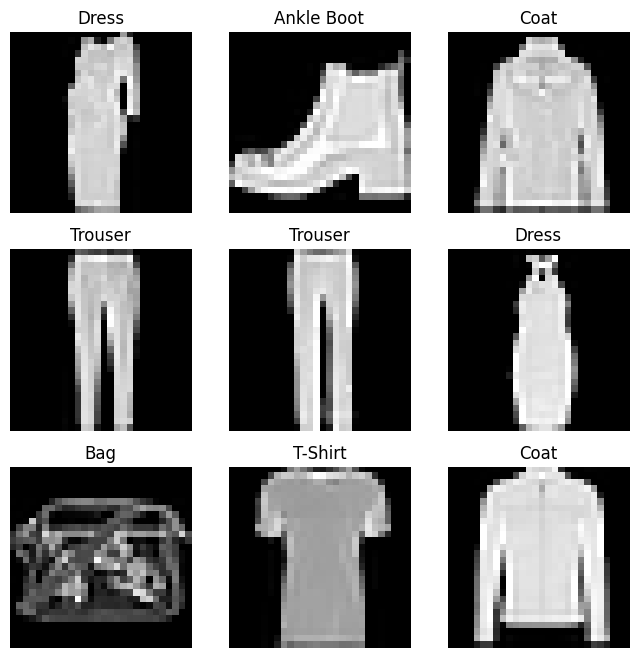

In [4]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

> **A question that often comes up here:** *"Why split into training and test sets again?"* For the same reason it has mattered in every model all course: the **test set is your honest exam.** The model is allowed to study the training photos as much as it likes, but you grade it only on the test photos it has never seen. If you scored it on images it had already memorized, the number would flatter the model and mislead the business that relies on it, exactly the trap that makes a churn model look brilliant in the slide deck and then disappoint in production. The discipline you have practiced since nb01 does not change just because the model is now a neural network.

> 📖 **Official PyTorch reference:** [Datasets & DataLoaders, official PyTorch tutorial](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html), which opens the full tutorial in a new browser tab.

## 4.2 Build the model

With the data flowing, you can build the network itself. First, a one-line piece of housekeeping: pick the **device**, the piece of hardware that will actually do the arithmetic. A **CPU** is the reliable, general-purpose processor in every computer, very good at doing one thing at a time. A **GPU** is a specialized chip that does thousands of small calculations at once, which is exactly the kind of work training a network demands, and it is a big part of why the field took off once affordable GPUs arrived. The line below quietly uses a GPU if Colab has given you one and falls back to the CPU otherwise. For the small network in this lab the CPU is perfectly fine; the GPU just makes it faster. One rule to keep in mind: the model and the data it processes must sit on the **same device**, or PyTorch will stop and complain.

In [5]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


Now describe the network. In PyTorch a model is written as a **class**: you list the layers it contains, and then, in the `forward` method, you say how a photo flows through them from input to answer. Read the comments in the code, where each layer has a plain-English job:

- **`Flatten`** takes the 28×28 grid of pixels and unrolls it into a single flat list of 784 numbers, one per pixel. The network never sees a "picture"; it sees a row of 784 brightness values, much like a row with 784 columns in a spreadsheet.
- **`Linear(784, 512)`** is the workhorse layer: 512 neurons, each one taking a **weighted vote** across all 784 input pixels. Those weights, more than 400,000 of them in this single layer, are exactly the numbers the network will tune as it learns. They start out random, which is precisely why an untrained model produces nonsense.
- **`ReLU`** is a tiny on/off switch applied after a `Linear` layer: it keeps positive values and replaces negatives with zero. That small kink is what lets the network bend to fit curved, complicated patterns. Without it, stacking layers would only ever produce straight-line relationships, no matter how many you piled up.
- The final **`Linear(512, 10)`** boils everything down to **10 numbers**, one raw score per clothing category. These raw, un-normalized scores have a name you will see constantly: **logits**.

In [6]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()                 # 28x28 image -> list of 784 numbers
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),                  # 784 inputs -> 512 neurons
            nn.ReLU(),                              # on/off switch (adds non-linearity)
            nn.Linear(512, 512),                    # 512 -> 512 (a hidden layer)
            nn.ReLU(),
            nn.Linear(512, 10),                     # 512 -> 10 category scores (logits)
        )

    def forward(self, x):                           # how data flows through the model
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


### Watch the data change shape, layer by layer

Layers can feel abstract until you watch real numbers move through them, so the next cell pushes a tiny mini-batch of **3 photos** through the first few pieces and prints the **shape** at each step. "Shape" just means the dimensions of the table of numbers, the way you would describe a spreadsheet as "1,000 rows by 12 columns." Watch the 3 photos start as a 3×28×28 block, get flattened to 3 lists of 784, then shrink to 3 lists of 20 after a small `Linear` layer. Tracking shapes like this is one of the most useful debugging habits in deep learning: when a model throws an error, a shape that is not what you expected is usually the culprit.

In [7]:
input_image = torch.rand(3, 28, 28)
print("start, 3 photos:           ", input_image.size())

flatten = nn.Flatten()
flat_image = flatten(input_image)
print("after Flatten, 3 lists:    ", flat_image.size(), "  (784 = 28x28)")

layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
print("after Linear(784->20):      ", hidden1.size())

print("\nBefore ReLU (first photo, first 8 values):\n", hidden1[0][:8])
hidden1 = nn.ReLU()(hidden1)
print("\nAfter ReLU (negatives are now 0):\n", hidden1[0][:8])

start, 3 photos:            torch.Size([3, 28, 28])
after Flatten, 3 lists:     torch.Size([3, 784])   (784 = 28x28)
after Linear(784->20):       torch.Size([3, 20])

Before ReLU (first photo, first 8 values):
 tensor([-0.7500,  0.0360,  0.4131,  0.5518, -0.9503, -0.5002, -0.2255,  0.1501],
       grad_fn=<SliceBackward0>)

After ReLU (negatives are now 0):
 tensor([0.0000, 0.0360, 0.4131, 0.5518, 0.0000, 0.0000, 0.0000, 0.1501],
       grad_fn=<SliceBackward0>)


Those 10 logits are raw, hard-to-read scores. To make them meaningful you pass them through **softmax**, which squeezes the 10 numbers into **probabilities** that are all positive and add up to 100%, for example "82% sneaker, 9% sandal, 4% ankle boot, and so on." Probabilities are what a business actually wants, because they carry a sense of **confidence** rather than just a bare guess; "we are 95% sure" and "we are 51% sure" call for very different decisions. Finally, **`argmax`** simply picks the category with the highest probability and reports it as the prediction.

But here is the catch: **the model has not been trained yet.** Its 400,000-plus weights are still the random values they were born with, so at this moment it is doing nothing more than guessing. The next cell proves it by asking the untrained model to classify one photo, so do not be surprised when it gets the answer wrong.

In [8]:
# One prediction with the UNTRAINED model, expect a wrong guess.
X0, y0 = test_data[0]
model.eval()                                   # evaluation mode
with torch.no_grad():                          # we're not training, so skip gradient tracking
    logits = model(X0.unsqueeze(0).to(device)) # add a "batch of 1" dimension, send to device
    probabilities = nn.Softmax(dim=1)(logits)  # logits -> probabilities
    guess = probabilities.argmax(1).item()     # index of the highest probability
print(f"Untrained guess: {labels_map[guess]}   |   Correct answer: {labels_map[y0]}")

Untrained guess: Ankle Boot   |   Correct answer: Ankle Boot


> 📖 **Official PyTorch reference:** [Build the Neural Network, official PyTorch tutorial](https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html), which opens the full tutorial in a new browser tab.

## 4.3 Train the model

This is the moment the network actually learns. Training is a loop: show the model some photos, measure how wrong it is, nudge its weights to be a little less wrong, and repeat that thousands of times. Three ingredients drive the loop, and each has a plain-English meaning:

- **Loss function**: a single number that measures *how wrong* the model is right now. Lower is better, exactly like a golf score. For sorting things into categories the standard choice is `CrossEntropyLoss`, which punishes the model more harshly the more confidently it is wrong.
- **Optimizer**: the "coach" that, after each batch, decides how to adjust every weight so the loss goes down. We use **SGD** (stochastic gradient descent), the small downhill step you watched in the gradient-descent video: feel which way is downhill, take a step, repeat.
- **Learning rate**: how *big* each of those steps is. Too small and training crawls along for ages; too big and it overshoots the target and bounces around without ever settling. `1e-3` (that is 0.001) is a safe, common starting value.

One last term: an **epoch** is one complete pass through all the training photos. We will run 5, so the model sees the full training set five times over.

In [9]:
learning_rate = 1e-3     # size of each weight nudge
epochs = 5               # how many full passes through the training data

loss_fn = nn.CrossEntropyLoss()                                   # the "wrongness" score
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) # the "coach"

# (model was set to eval() above; the train loop will switch it back to train())

The next cell defines the two routines that do the real work, one for learning and one for checking:

- **`train_loop`** walks through the training data one batch at a time and, for each batch, runs the three-step update you saw in the videos. `loss.backward()` works out which direction is "downhill" for every weight (this is backpropagation), `optimizer.step()` takes one step in that direction, and `optimizer.zero_grad()` wipes the slate clean before the next batch. This is the only place the model is ever allowed to change.
- **`test_loop`** walks through the held-out test data and reports two honest scorecards, **accuracy** (the share of photos it labeled correctly) and average loss, *without* adjusting a single weight. It is the model's report card, not a study session.

Splitting "learning" and "checking" into two separate loops keeps the honest-exam discipline front and center: the model only ever learns from the training set, and you only ever judge it on the test set.

In [10]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()                                  # training mode
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        pred = model(X)                            # 1. predict this batch
        loss = loss_fn(pred, y)                    # 2. how wrong were we?

        loss.backward()                            # 3a. which way is downhill? (backprop)
        optimizer.step()                           # 3b. take a step downhill
        optimizer.zero_grad()                      # 3c. reset for the next batch

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"  loss: {loss:>7f}  [{current:>5d}/{size:>5d} photos]")


def test_loop(dataloader, model, loss_fn):
    model.eval()                                   # evaluation mode
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():                          # no learning during the exam
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"  Test accuracy: {(100*correct):>0.1f}%   |   Avg loss: {test_loss:>8f}\n")

Now run it. As the epochs tick by, watch for two numbers moving in the right direction: the **loss falling** and the **test accuracy climbing**. Seeing those two trends together is what "learning" looks like in practice, and it is genuinely satisfying the first time you watch a network you built improve in real time. This is the slowest cell in the notebook, so expect a couple of minutes on a CPU, or just seconds if Colab handed you a GPU.

In [11]:
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
  loss: 2.310409  [   64/60000 photos]
  loss: 2.299019  [ 6464/60000 photos]
  loss: 2.273115  [12864/60000 photos]
  loss: 2.268872  [19264/60000 photos]
  loss: 2.257739  [25664/60000 photos]
  loss: 2.241122  [32064/60000 photos]
  loss: 2.246378  [38464/60000 photos]
  loss: 2.213534  [44864/60000 photos]
  loss: 2.204479  [51264/60000 photos]
  loss: 2.194243  [57664/60000 photos]
  Test accuracy: 35.5%   |   Avg loss: 2.176248

Epoch 2
-------------------------------
  loss: 2.173031  [   64/60000 photos]
  loss: 2.168247  [ 6464/60000 photos]
  loss: 2.157089  [12864/60000 photos]
  loss: 2.116462  [19264/60000 photos]
  loss: 2.070319  [25664/60000 photos]
  loss: 2.102592  [32064/60000 photos]
  loss: 2.045143  [38464/60000 photos]
  loss: 2.064508  [44864/60000 photos]
  loss: 2.025397  [51264/60000 photos]
  loss: 1.964753  [57664/60000 photos]
  Test accuracy: 49.6%   |   Avg loss: 1.934964

Epoch 3
-------------------------------
  

> **A question that often comes up here:** *"My accuracy is only around 65–70%, is something broken?"* Not at all. That is exactly what five quick passes of plain SGD give this deliberately simple network, and it matches the official Quickstart's own result. Keep the floor in mind: random guessing across 10 categories would land near 10%, so a model sitting at 65–70% has very clearly learned something real. If you wanted to push it higher, the usual levers are to train for **more epochs**, swap the optimizer to **`Adam`** (which often learns faster), or move to a **convolutional network (CNN)**, a design built specifically for images that routinely clears 90% on this dataset; you will meet CNNs by name a little later in this notebook. The takeaway for a business audience is that "good enough to prove the idea works" and "tuned and ready for production" are two different bars, and you have just cleared the first one.

> 📖 **Official PyTorch reference:** [Optimizing Model Parameters, official PyTorch tutorial](https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html), which opens the full tutorial in a new browser tab.

## 4.4 Save the model

Your model just spent a couple of minutes learning, and in a real project that training might take hours or days on expensive hardware. You do not want to repeat it every time someone needs a prediction. PyTorch keeps everything the model learned, all of those carefully tuned weights, in a **state dictionary** (`state_dict`), which you can picture as the model's "brain settings." Writing that dictionary to a file means you can reload the fully trained model in an instant later, share it with a teammate, or hand it to an engineering team to drop into a production system. This is the neural-network version of the `joblib` model-saving you did in nb18: train once, save, then reuse the result anywhere.

In [12]:
torch.save(model.state_dict(), "model.pth")
print("Saved the trained model to model.pth")

Saved the trained model to model.pth


## 4.5 Load the model back

Loading is the mirror image of saving, and it is a two-step move that trips up a lot of beginners. First you build a fresh, empty copy of the model from the class definition, because the class is only the **blueprint**, the wiring diagram, and a brand-new copy starts out with random weights again. Then you pour the saved `state_dict` back in, which overwrites those random weights with the trained ones you worked so hard to produce. One habit worth locking in: always call `model.eval()` before using a loaded model to make predictions. That switches the model into "evaluation mode," telling certain layers to behave the way they should when scoring real cases rather than when training.

In [13]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth", weights_only=True))
model.eval()
print("Reloaded the trained model from disk, ready to predict.")

Reloaded the trained model from disk, ready to predict.


## 4.6 Predict: the payoff

This is what the whole exercise was for. A trained model only becomes valuable when it makes predictions on data it has never seen, the same way a churn model only earns its keep when it flags next month's at-risk customers, not last month's. The cell below hands the model the first photo from the test set, reads back the category it predicts, and prints the true label right beside it so you can judge for yourself whether it got it right. The very same network that produced nonsense a few cells ago should now be correct.

In [14]:
model.eval()
x, y = test_data[0][0], test_data[0][1]
with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    predicted, actual = labels_map[pred[0].argmax(0).item()], labels_map[y]
print(f'Predicted: "{predicted}"   |   Actual: "{actual}"')

Predicted: "Ankle Boot"   |   Actual: "Ankle Boot"


### 🎲 Predict a grid of random photos

One prediction is convincing; nine at a glance is more fun and more honest. The cell below draws **nine random test photos**, runs each through your trained model, and labels every image with its predicted category over its true category, printing the title in **green** when the model is right and **red** when it slips. Run it a few times to pull a fresh nine. With a trained model most titles come up green, and the occasional red one is instructive: look at the misses and you will often find the model confusing genuinely similar items, such as a shirt and a coat, the same kind of mistake a hurried person might make.

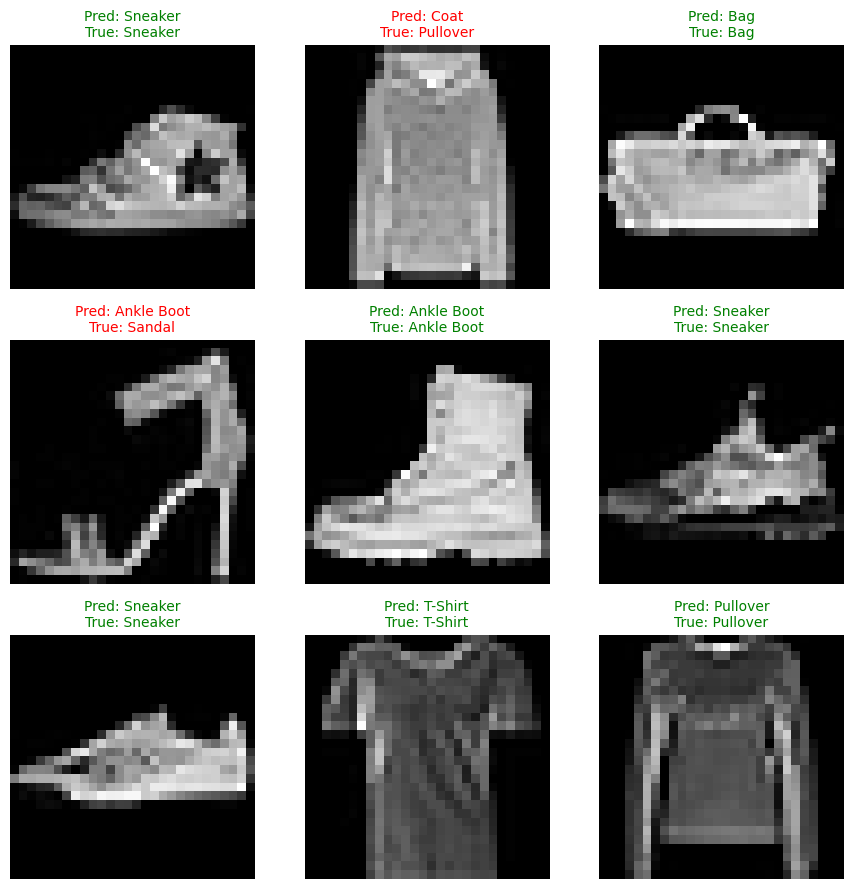

In [15]:
model.eval()
figure = plt.figure(figsize=(9, 9))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    idx = torch.randint(len(test_data), size=(1,)).item()
    img, true_label = test_data[idx]
    with torch.no_grad():
        pred_label = model(img.unsqueeze(0).to(device)).argmax(1).item()
    is_correct = (pred_label == true_label)
    figure.add_subplot(rows, cols, i)
    plt.title(f"Pred: {labels_map[pred_label]}\nTrue: {labels_map[true_label]}",
              color=("green" if is_correct else "red"), fontsize=10)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.tight_layout()
plt.show()

> **A question that often comes up here:** *"The untrained model in 4.2 guessed wrong, and now most guesses are right, what actually changed?"* Only the **weights**. The model's structure, the layers and the `forward` path the data travels, never moved an inch. All that training did was adjust the hundreds of thousands of numbers inside the `Linear` layers, one small downhill step at a time, until the very same calculation that once produced nonsense now maps a clothing photo to the correct category most of the time. That is the entire story of supervised deep learning in one sentence: **fixed structure, learned weights, and a loss function quietly pulling those weights toward "right."** And you just ran the whole arc end to end, load, build, train, save, load, predict, which is a complete, real-world machine-learning pipeline in PyTorch.

# 5. When to Use Deep Learning

You have now trained a neural network with your own hands, which earns you the right to answer the VP's question honestly rather than reflexively. So: *should TechCorp be using deep learning?* The grown-up answer is **"it depends, and for most tabular business data, no."** That is not a knock on deep learning; it is a statement about matching the tool to the job, the same way you would not rent a freight truck to deliver a single envelope. This section gives you the judgment, and a simple rubric, to make that call with confidence and defend it in a meeting.

## First, the three "shapes" deep learning was built for

The single most useful idea here is that the *shape* of your data, far more than how fashionable a method is, decides which design fits. Three families cover almost everything you will meet, and you only need the headline for each:

- **MLP (Multilayer Perceptron), the plain stack of fully connected layers you just built.** The name is historical: a "perceptron" is a single artificial neuron, and an MLP is simply many of them stacked in layers. It accepts any flat list of numbers, so it is the general-purpose option and the one you will put head-to-head with gradient boosting in a moment. Picture the kind of data that lives happily in a spreadsheet.
- **CNN (Convolutional Neural Network), built for images.** The "convolutional" part is the trick: the network slides small "pattern detectors" across a picture, so it can recognize a sleeve whether it sits in the corner or dead center. That spatial awareness is why CNNs dominate anything visual and would comfortably beat the simple MLP you trained on FashionMNIST. Self-driving-car vision, medical-scan reading, and automatic product-photo tagging all run on CNNs.
- **RNN (Recurrent Neural Network) and Transformer, built for sequences.** "Recurrent" means the network feeds its own output back in as it steps through a sequence, giving it a form of memory. These handle data that arrives *in order*, where position carries meaning: text, audio, and time series. The Transformer, the modern member of this family, is the engine behind ChatGPT, Claude, and Gemini, which is why it gets its own special-topic section at the end of this notebook.

A well-known image benchmark, **CIFAR-100**, gives a feel for the kind of rich visual task CNNs were designed to crack:

<center>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/cifar100.png" alt="CIFAR-100 sample images" width="560"/>
<br>
<small>CIFAR-100: 60,000 small color photos across 100 categories. The kind of rich, varied visual task where a CNN's edge over a plain network becomes obvious.</small>
</center>

## Simpler is often better: flexibility vs. interpretability

Deep learning's superpower is **flexibility**: with enough data it can bend to fit almost any pattern you throw at it. But that power comes with a bill, and the bill is **interpretability**. A highly flexible model becomes a **black box** that can be accurate while being nearly impossible to explain in plain English to a regulator, a skeptical executive, or the customer whose loan application you just declined. This is not a new idea in the course; it is the very same flexibility-versus-interpretability trade-off you met on day one, now with deep learning sitting at the far, most-flexible end of the curve:

<center>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/2_7-1.png" alt="Flexibility vs interpretability" width="560"/>
<br>
<small>More flexible models (like deep learning) are harder to interpret. Prefer the simplest model that does the job.</small>
</center>

**Occam's razor for analysts:** when a simpler, explainable model performs about as well, choose it, and the reason is practical rather than aesthetic. A churn model your retention team can *understand and trust* actually gets acted on, while a slightly-more-accurate black box they do not trust tends to get quietly ignored, and a model nobody acts on creates zero value no matter how clever it is. Accuracy you cannot deploy is worth little; clarity that drives action is worth a great deal.

## The four-question rubric

Before reaching for deep learning on a business problem, run it through these four questions. Each one is really asking the same thing: *does this problem have what deep learning needs to justify its extra cost?*

1. **Data shape.** Is the input a **rich object** like an image, an audio clip, or a long stretch of text? → lean deep learning, since that is exactly what CNNs and Transformers were built for. Is it a **tabular row**, a spreadsheet of customer attributes? → lean classical ML, the trees and boosting you already know.
2. **Sample size.** Do you have **tens of thousands** of labeled examples, ideally millions? → deep learning has the fuel it needs to shine. Only hundreds or a few thousand rows? → classical ML almost always wins, because deep networks starve on small data.
3. **Compute budget.** Can you afford roughly **10× the training time and 50× the prediction cost** of a tree ensemble, counting both hardware and engineering hours? → deep learning is in scope. Need millisecond predictions on a laptop or a tight cloud bill? → classical ML.
4. **Interpretability need.** Does a stakeholder, a regulator, or a customer need a clear **per-prediction explanation**? → classical ML is far friendlier, since deep learning's explanations are approximate at best. Only raw accuracy matters and nobody will ask "why"? → deep learning is fine.

**Decision rule:** you need a **"yes" to at least three of the four** before deep learning is the right *primary* tool. Fall short of that and you should start with classical ML, which is exactly where the vast majority of tabular business problems land.

## 📝 PAUSE-AND-DO Exercise 1: When Is Deep Learning the Right Tool? (10 minutes)

**Task:** Apply the four-question rubric to **two** problems from this course: the Bank Churn case competition (nb18) and the US retail-employment forecast (nb16). For each, answer the four questions and give one verdict: *deep learning is / is not the right primary tool.*

### YOUR RUBRIC ANSWERS HERE:

**Problem A: Bank Churn case competition (tabular, \~10K rows, predict churn probability for the retention team):**

1. Data shape: *[Tabular]*
2. Sample size: *[around 10,000 rows making is a medium sized dataset]*
3. Compute budget: *[lean]*
4. Interpretability: *[high]*
5. **Verdict:** *[Classical ML primary]*: *[A Classical ML primary (gradient boosting or random forest model) will most likely either draw or have better resutls than a neural network in this case because of the lean computing budget meaning that they can run on seconds on a laptop, the moderate size of the sample, Tabular datasets which works well with classical ML and the high interpretability.]*

**Problem B: US retail-employment forecast (\~80 years of monthly BLS history, one-year workforce-planning horizon):**

1. Data shape: *[Sequential (Time Series)]*
2. Sample size: *[around 960 data points]*
3. Compute budget: *[lean]*
4. Interpretability: *[medium]*
5. **Verdict:** *[Classical ML primary]*: *[Classical ML is still most likely best for this situation mainly because the size is too small for deep learning to find any meaningful patters that a linear regression or time seres model couldn't find if not more reliably.]*

## An honest demo: deep learning vs the nb14 champions, on both business cases

Talk is cheap, so let's settle the question with evidence, on the two datasets that ran through this whole course and against the exact models nb14 crowned as champions.

- **MedScreen (Breast Cancer), a classification problem.** 569 patients, 30 tumor-scan features, a benign-or-malignant label. In nb14 the champion turned out to be the humble **logistic regression** `LogReg(C=1.0)` from Week 2: the random forest and the tuned gradient-boosting machine competed admirably, but their confidence intervals never cleared it, so by the CI-overlap rule the simplest model kept the crown.
- **HomeValue (California Housing), a regression problem.** About 20,000 neighborhoods, 8 features, predicting median house value. Here nb14's champion is the **tuned gradient-boosting machine** `GradientBoostingRegressor(lr=0.2, n=200, max_features=0.5, max_depth=3)` from nb13, which beat every linear model and edged out the random forest.

The question for this section is blunt: **can a neural network beat either champion on its home turf?** In the cell below we drop a standard `MLPClassifier` and `MLPRegressor` (each behind a `StandardScaler`) into the same 5-fold cross-validation, on the same folds, scored with the same metrics and the Student's *t* 95% confidence intervals you have used since nb08. We then plot each contest as a confidence-interval chart and read off the verdict. (This runs two real cross-validations, one of them on 20,000+ rows, so give it up to a minute.)

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor

RANDOM_SEED = 474
np.random.seed(RANDOM_SEED)
k = 5
t_crit = stats.t.ppf(0.975, df=k - 1)   # ~2.776, the Student's t constant from nb08

def ci95(scores):
    """CV mean and 95% Student's t CI half-width (k = 5 folds)."""
    m = float(np.mean(scores)); sd = float(np.std(scores, ddof=1))
    return m, t_crit * sd / np.sqrt(k)

def verdict(champ_m, champ_h, mlp_m, mlp_h, higher_is_better=True):
    """Champion vs MLP via 95% CI overlap, phrased from deep learning's side."""
    lo = max(champ_m - champ_h, mlp_m - mlp_h)
    hi = min(champ_m + champ_h, mlp_m + mlp_h)
    if lo <= hi:
        return "STATISTICAL TIE: deep learning does not beat the champion"
    champ_better = (champ_m > mlp_m) == higher_is_better
    return ("CHAMPION WINS (CI-clear): deep learning loses" if champ_better
            else "DEEP LEARNING WINS (CI-clear)")

# ---------- Case 1: MedScreen, Breast Cancer (classification) ----------
Xc, yc = load_breast_cancer(return_X_y=True, as_frame=True)
cv_clf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_SEED)
champ_clf = Pipeline([("scaler", StandardScaler()),          # nb14 classification champion
                      ("clf", LogisticRegression(C=1.0, max_iter=5000, random_state=RANDOM_SEED))])
mlp_clf   = Pipeline([("scaler", StandardScaler()),
                      ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_SEED))])
auc_champ = cross_val_score(champ_clf, Xc, yc, scoring="roc_auc", cv=cv_clf, n_jobs=-1)
auc_mlp   = cross_val_score(mlp_clf,   Xc, yc, scoring="roc_auc", cv=cv_clf, n_jobs=-1)

# ---------- Case 2: HomeValue, California Housing (regression) ----------
Xr, yr = fetch_california_housing(return_X_y=True, as_frame=True)
cv_reg = KFold(n_splits=k, shuffle=True, random_state=RANDOM_SEED)
champ_reg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.2,    # nb14 regression champion
                                      max_features=0.5, max_depth=3, random_state=RANDOM_SEED)
mlp_reg   = Pipeline([("scaler", StandardScaler()),
                      ("reg", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_SEED))])
r2_champ = cross_val_score(champ_reg, Xr, yr, scoring="r2", cv=cv_reg, n_jobs=-1)
r2_mlp   = cross_val_score(mlp_reg,   Xr, yr, scoring="r2", cv=cv_reg, n_jobs=-1)

# ---------- Means, 95% CIs, verdicts ----------
cm, ch   = ci95(auc_champ); mm, mh   = ci95(auc_mlp)
rcm, rch = ci95(r2_champ);  rmm, rmh = ci95(r2_mlp)
v_clf = verdict(cm, ch, mm, mh)
v_reg = verdict(rcm, rch, rmm, rmh)

summary = pd.DataFrame({
    'Business case':  ['MedScreen (Breast Cancer)', 'MedScreen (Breast Cancer)',
                       'HomeValue (Calif. Housing)', 'HomeValue (Calif. Housing)'],
    'Model':          ['nb14 champion: LogReg(C=1.0)', 'Deep learning: MLP (64,32)',
                       'nb14 champion: tuned GBM',      'Deep learning: MLP (64,32)'],
    'Metric':         ['ROC-AUC', 'ROC-AUC', 'R2', 'R2'],
    'CV mean':        [cm, mm, rcm, rmm],
    '95% CI half-w':  [ch, mh, rch, rmh],
})
print(summary.round(4).to_string(index=False))
print(f"\nMedScreen (classification) verdict:  {v_clf}")
print(f"HomeValue (regression)     verdict:  {v_reg}")

# ---------- The money plots: deep learning vs champion, with 95% CIs ----------
GREY, BLUE, ORANGE = '#999999', '#1f77b4', '#ff7f0e'
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

def ci_panel(ax, labels, means, halfs, colors, metric, title):
    for i, (m, h, c) in enumerate(zip(means, halfs, colors)):
        ax.errorbar(m, i, xerr=h, fmt='o', capsize=8, markersize=12, linewidth=3, color=c)
        ax.text(m, i + 0.18, f"{m:.4f} \u00b1 {h:.4f}", ha='center', va='bottom', fontsize=10)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_ylim(-0.6, len(labels) - 0.2)
    ax.set_xlabel(f'5-fold CV {metric} (mean \u00b1 95% CI)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

ci_panel(axes[0], ['Champion\nLogReg(C=1.0)', 'Deep learning\nMLP (64,32)'],
         [cm, mm], [ch, mh], [GREY, BLUE], 'ROC-AUC',
         f'MedScreen (classification)\n{v_clf}')
ci_panel(axes[1], ['Champion\ntuned GBM', 'Deep learning\nMLP (64,32)'],
         [rcm, rmm], [rch, rmh], [GREY, ORANGE], 'R\u00b2',
         f'HomeValue (regression)\n{v_reg}')
fig.suptitle('Deep learning (MLP) vs the nb14 champions, on identical CV folds',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

**Reading the output:** Look at the two confidence-interval charts. In **neither** case does the neural network win.

On **MedScreen** the contest is a dead heat: the champion logistic regression and the MLP both sit up around **0.99 ROC-AUC**, with confidence intervals that lie almost on top of each other. A clean statistical tie, and the tie goes to the model an oncologist can actually explain.

On **HomeValue** the champion gradient-boosting machine posts a clearly higher mean R² (about **0.82** against the MLP's **0.79**), and although the two intervals still graze each other at five folds (so we stop short of declaring a CI-clear knockout), the neural network is plainly not ahead. This is the more telling result, because California Housing has the **20,000+ rows** the rubric says should finally play to deep learning's strengths. The data is there, and the MLP still does not win.

Taken together, the two charts are the empirical backbone of this whole section: on ordinary tabular business data, a neural network at best ties a simpler, cheaper, more explainable model, and often trails it. The picture only flips when the input becomes an image (like the FashionMNIST photos you trained on) or long text, where the specialized architectures pull decisively ahead.

> **A question that often comes up here:** *"What if I just make the neural network bigger?"* It is a reasonable instinct, so test it in the next exercise. On tables shaped like these, adding layers does not push the AUC or R² past the champion's interval; it only spends more training time and invites unstable, fiddly training. The most useful lesson in applied machine learning hides in plain sight here: **bigger is not better when the data does not demand bigger.**

## 📝 PAUSE-AND-DO Exercise 2: Compare and Decide (10 minutes)

**Task:** Give deep learning its best shot on **MedScreen**. Add a **deeper** neural network with `hidden_layer_sizes=(128, 64, 32)` to the classification bake-off, run it on the **same folds** (`cv_clf`), and check whether the extra depth finally lets it clear the `LogReg(C=1.0)` champion's confidence interval. Then write three sentences answering the VP of Strategy's question.

**Hints:**
- Copy the `mlp_clf` pipeline; only the `hidden_layer_sizes` argument changes.
- Score it with `cross_val_score(..., scoring="roc_auc", cv=cv_clf)` and reuse the `ci95` helper from the demo.
- Do **not** change `cv_clf`: identical folds are what make the comparison fair.

In [ ]:
# YOUR SOLUTION CODE HERE
# Give deep learning its best shot with a deeper architecture
deep_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=700,
                          random_state=RANDOM_SEED)),
])

# Score it using the same CV folds and ROC-AUC metric
auc_deep = cross_val_score(deep_clf, Xc, yc, scoring="roc_auc", cv=cv_clf, n_jobs=-1)
deep_mean, deep_half = ci95(auc_deep)

# Display results to compare against the champion
print(f"Champion LogReg AUC: {cm:.4f} ± {ch:.4f}")
print(f"Deeper MLP (128,64,32) AUC: {deep_mean:.4f} ± {deep_half:.4f}")

# Check for CI clear knockout
lo_deep = deep_mean - deep_half
hi_champ = cm + ch

if lo_deep > hi_champ:
    print("\nVERDICT: The deeper model CLEARLY BEATS the champion.")
else:
    print("\nVERDICT: Still a statistical tie or trailing; depth did not provide a knockout win.")

### YOUR ANSWER TO THE VP HERE:

**Three sentences for the VP of Strategy:**

1. *[Empirical comparison: even after increasing the depth of the model, the neural network only managed to have a statistical draw with the champion linear regression but actually fell behind the tuned gradient boosting model with CI showing that there's no clear winner for deep learning for this particular data]*
2. *[Why this generalizes to the Bank Churn problem: These results generalize because its applied directly to our bank churn modeling problem and due to that data being tabular as well as having a medium sample size (around 10,000 rows), it allows for the conditions where classical ML models typically match or improve in comparison to the deep learning methods.]*
3. *[Where deep learning **would** earn its keep at TechCorp: Deep learning would be better for this company if they were processing unstructured data like categorizing images or something along those lines.]*

# 6. Special Topic: Large Language Models (LLMs)

Every AI tool you have used this course, Gemini, ChatGPT, Claude, is a **Large Language Model (LLM)**: a transformer (the sequence network from Section 3) trained on a huge slice of the internet to do one deceptively simple thing, **predict the next word**. Do that well enough, billions of times over, and the model absorbs grammar, facts, reasoning patterns, and a working sense of tone, all as a side effect of getting good at "guess what comes next."

You will never train one from scratch (that takes thousands of GPUs and months of compute), and you do not need to. Your job as an analyst is to **use** them well and to **explain them credibly** when a manager asks. This section gives you both. First, the mental model: what an LLM actually is and how a business puts one to work. Then a **hands-on lab where you run a real LLM in code** on customer reviews and support tickets, no training, no GPU, and no API key required.

Start with these four short, friendly explainers from 3Blue1Brown. They take you from "what is an LLM?" to how its attention and memory work. **Click any thumbnail** to watch.

<div align="center">
<a href="https://www.youtube.com/watch?v=LPZh9BOjkQs" target="_blank"><img src="https://img.youtube.com/vi/LPZh9BOjkQs/hqdefault.jpg" alt="Large Language Models explained briefly" width="480"></a>
<br>
▶️ <b><a href="https://www.youtube.com/watch?v=LPZh9BOjkQs" target="_blank">Large Language Models explained briefly</a></b> <i>(click the image or link to watch)</i>
</div>

<div align="center">
<a href="https://www.youtube.com/watch?v=wjZofJX0v4M" target="_blank"><img src="https://img.youtube.com/vi/wjZofJX0v4M/hqdefault.jpg" alt="Transformers, the tech behind LLMs" width="480"></a>
<br>
▶️ <b><a href="https://www.youtube.com/watch?v=wjZofJX0v4M" target="_blank">Transformers, the tech behind LLMs</a></b> <i>(click the image or link to watch)</i>
</div>

<div align="center">
<a href="https://www.youtube.com/watch?v=eMlx5fFNoYc" target="_blank"><img src="https://img.youtube.com/vi/eMlx5fFNoYc/hqdefault.jpg" alt="Attention in transformers, step-by-step" width="480"></a>
<br>
▶️ <b><a href="https://www.youtube.com/watch?v=eMlx5fFNoYc" target="_blank">Attention in transformers, step-by-step</a></b> <i>(click the image or link to watch)</i>
</div>

<div align="center">
<a href="https://www.youtube.com/watch?v=9-Jl0dxWQs8" target="_blank"><img src="https://img.youtube.com/vi/9-Jl0dxWQs8/hqdefault.jpg" alt="How might LLMs store facts" width="480"></a>
<br>
▶️ <b><a href="https://www.youtube.com/watch?v=9-Jl0dxWQs8" target="_blank">How might LLMs store facts</a></b> <i>(click the image or link to watch)</i>
</div>

## 6.1 What an LLM actually is (and what it is not)

Strip away the hype and an LLM is a **next-token predictor**. Hand it the text "The customer was very" and it returns a probability for every possible next token, maybe `happy` at 18%, `upset` at 11%, `satisfied` at 9%, and so on. It picks one, appends it, and repeats. Everything an LLM does, answering a question, writing SQL, summarizing a contract, is that loop running over and over. There is no lookup table of answers inside; there is a giant pile of weights that encode patterns, learned by exactly the gradient-descent loop you ran in Section 4, just scaled to hundreds of billions of weights and trillions of words.

A handful of terms come up in almost any business AI conversation. Here they are in plain language:

- **Token:** the unit an LLM reads and writes, roughly 3/4 of a word. "Predictive analytics" is about 3 tokens. APIs bill *per token*, so a token is literally the unit of cost.
- **Context window:** how much text the model can "see" at once, its short-term memory, measured in tokens. A 128k-token window lets a model read a \~200-page document in one shot; older models ran out of room after a few pages.
- **Temperature:** a dial from 0 to \~1 that controls randomness. Low (0&ndash;0.2) gives focused, repeatable answers, what you want for pulling fields out of data. Higher gives more varied, creative output, useful for brainstorming.
- **Hallucination:** because the model predicts *plausible* text, not *true* text, it can state false things with total confidence, an invented citation, a made-up number, a policy that does not exist. This is the single biggest risk for business use. **Always verify anything that matters.**

> **A question that often comes up here:** *"Will I ever train one of these?"* Almost certainly not, and you do not need to. As a business analyst you will **use** LLMs through an API (exactly what you have done all course with Gemini prompts), not build them from scratch. But notice the through-line: the LLM learns the *same way* the network you built in Section 4 did, data in, a loss measuring wrongness, gradient descent nudging weights, just at an astronomically larger scale. You already understand the core loop; the rest is engineering and electricity.

## 6.2 How a business analyst actually uses an LLM

An LLM shows up in your work in three ways, in rising order of analyst skill:

1. **The chat box.** You type into Gemini or ChatGPT and read the reply, exactly what you have done all course. Perfect for a one-off question; impossible to scale to 10,000 reviews.
2. **The API, from code.** You send text to the model *programmatically* and get structured output back, so you can run it across an entire spreadsheet, a folder of contracts, or a live stream of support tickets. **This is the skill that separates an analyst from a casual user**, and it is what you will practice below.
3. **Embedded in a product.** The LLM is wired into a pipeline, autocomplete, a support bot, a fraud-summary tool, and runs untouched by human hands. Building these is an engineering job, but you will be the one who specifies and evaluates them.

Whichever mode, output quality is dominated by the **prompt**. Three rules carry most of the weight:

- **Be specific about the task and the format.** "Classify this ticket as Billing, Technical, or Sales, and reply with only the label" beats "what is this ticket about?"
- **Show an example or two** when the task is fuzzy: "here are two tickets already labeled, now label the third." This is *few-shot prompting*, and it often beats a paragraph of instructions.
- **Give the model an out.** "If the text fits none of the categories, answer Unknown" heads off confident nonsense.

> **A question that often comes up here:** *"Is prompt engineering a real skill, or just typing?"* It is real, and it is measurable. The same model can score 60% or 90% on the identical classification task depending only on how the prompt is worded, how the categories are named, and whether you let it say "I don't know." You will see this firsthand in the lab: changing the candidate labels changes the answer, even though the model itself never changed.

## 6.3 Hands-On Lab: Run a Real LLM in Code

Enough talk, let us run one. You will use [**Hugging Face**](https://huggingface.co/) `transformers`, the most popular open-source library for working with these models. It hands you a one-line tool called a **pipeline** that downloads a pre-trained model and applies it to your text: no training, no GPU, no API key. Everything below runs on the free Colab CPU.

You will tackle two genuine business tasks, the exact "read the free text" jobs where deep learning earns its keep:

1. **Sentiment analysis**, is this customer happy or angry?
2. **Zero-shot classification**, route a support ticket to the right team *without a single labeled training example*.

Run the next cell to install and import the library (\~20&ndash;30 seconds the first time).

In [ ]:
# Hugging Face transformers gives us ready-to-use LLMs in one line of code.
# Colab already has PyTorch installed; we just add the transformers library.
!pip install transformers -q

from transformers import pipeline
import pandas as pd

print("transformers is ready. We can now load pre-trained language models.")

### 6.3a Is this customer happy or angry? (sentiment analysis)

Your first model is a **sentiment classifier**, a small LLM fine-tuned to read a sentence and label it `POSITIVE` or `NEGATIVE` with a confidence score. This is a *classifier*, exactly like the logistic regression and gradient boosting you built earlier, except the input is raw English instead of numeric columns. That is the leap LLMs give you: **machine learning on words**.

The first time you run the next cell it downloads a \~270 MB model, then labels six customer reviews in a fraction of a second each.

In [ ]:
# Load a sentiment classifier. The first run downloads the model (~270 MB).
sentiment = pipeline("sentiment-analysis")

reviews = [
    "The dashboard is fast and the support team fixed my issue in minutes.",
    "I was charged twice and nobody has answered my emails for a week.",
    "Setup was a little confusing, but once it worked I loved the product.",
    "Absolutely terrible. Cancelling my subscription today.",
    "Does exactly what it promises. No complaints.",
    "The new update broke my workflow and I am extremely frustrated.",
]

results = sentiment(reviews)

for review, r in zip(reviews, results):
    print(f"[{r['label']:8} {r['score']:.0%}]  {review}")

**Reading the output:** Each review now carries a label and a confidence. The clear cases, "Absolutely terrible" and "fixed my issue in minutes", come back at \~99% confidence. The mixed review ("a little confusing, but ... I loved the product") is the interesting one: the model weighs the competing signals and lands on POSITIVE, typically with lower confidence than the clear-cut cases. You just classified free text with **zero feature engineering**, the model already learned, from its training data, what words like *terrible*, *loved*, and *frustrated* signal.

> **A question that often comes up here:** *"How is this different from just searching for the word 'terrible'?"* A keyword search is brittle: it misses sarcasm ("oh great, charged twice again"), negation ("not bad at all"), and synonyms no one listed. The LLM learned meaning from context across billions of sentences, so it handles phrasings nobody hard-coded. That robustness is exactly why a bank routes millions of support messages through a model like this instead of a keyword list.

### 6.3b Routing support tickets with zero training (zero-shot classification)

The sentiment model only knows two labels, POSITIVE and NEGATIVE, because that is what it was trained on. But real business problems use *your* categories: route this ticket to **Billing**, **Technical Support**, **Account Management**, or **Sales**. Normally that would demand a labeled training set.

**Zero-shot classification** removes that requirement. You hand the model the text *and* your list of candidate labels at run time, and it scores how well each label fits, having never been trained on your categories at all. Change the labels and the model adapts instantly. This is the closest thing in the lab to the "magic" of modern LLMs.

The next cell downloads a larger model (\~1.6 GB, give it a moment) and routes five incoming tickets.

In [ ]:
# Zero-shot classification: the model scores labels it was never trained on.
# First run downloads ~1.6 GB. (For a faster, smaller option, swap in
# model="valhalla/distilbart-mnli-12-1".)
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

tickets = [
    "I was double-charged on my last invoice and need a refund.",
    "The app crashes every time I try to upload a CSV file.",
    "I'd like to add three new users to our company account.",
    "Can you walk me through your enterprise pricing tiers?",
    "My password reset link expired before I could use it.",
]

candidate_labels = ["Billing", "Technical Support", "Account Management", "Sales"]

rows = []
for ticket in tickets:
    out = classifier(ticket, candidate_labels)
    rows.append({
        "ticket": ticket,
        "routed_to": out["labels"][0],
        "confidence": round(out["scores"][0], 2),
    })

routing = pd.DataFrame(rows)
print(routing.to_string(index=False))

**Reading the output:** Every ticket landed in a sensible queue, the double-charge to Billing, the crash to Technical Support, the pricing question to Sales, and you wrote **zero training examples**. You only named the categories. For a support team drowning in tickets this is transformative: adding a new category ("Cancellations") is a one-line edit, not a project to collect and label thousands of examples and retrain a model.

> **A question that often comes up here:** *"If it needs no training data, why did we spend the whole course building models?"* Two reasons. First, zero-shot is convenient but not free: the model is huge and slower, and a focused classifier trained on *your* labeled data is usually more accurate and far cheaper to run at scale. Second, most business problems are **tabular**, the churn table, the sales forecast, where, as Section 5 showed, gradient boosting still wins. LLMs shine specifically when the input is **unstructured text or images** and you lack labeled data. Knowing *which* tool fits *which* problem is the judgment this whole course has been building.

## 6.4 Scaling Up: Calling a Hosted LLM via API (optional)

The Hugging Face models above run *on your machine*, free and private, but they are small. For frontier-quality answers, the kind Gemini, ChatGPT, and Claude give, you call a **hosted** model over an API: you send text, a data center runs a giant model, and the reply comes back. The useful part is that **the code shape is almost identical across providers**, you POST your text with an API key; only the URL, one header, and the model name change. Here are the options worth knowing, free ones first.

**Free options**

**Option 1, Purdue GenAI Studio (your best bet at Purdue).** Purdue's Rosen Center for Advanced Computing hosts open models (LLaMA and others) free for the Purdue community at <https://genai.rcac.purdue.edu/>. Sign in with your Purdue SSO, then click your avatar &rarr; **Settings &rarr; Account** to find your **API Keys**. The endpoint is OpenAI-compatible. ⚠️ It is a pilot service with limited safety measures, **never send sensitive, proprietary, or personal data**.

**Option 2, Google Gemini API.** The same Gemini you used all course has a free API tier. Grab a key at <https://aistudio.google.com/apikey>.

**Option 3, Hugging Face Inference API.** A free tier for hosted open models. Create a token at <https://huggingface.co/settings/tokens>.

**Industry-standard paid options**

These two are what most companies actually build on. Both need a billing account and charge **per token** (a fraction of a cent per request for the small models), so treat your key like a password and never paste it into a shared notebook or commit it to GitHub.

**Option 4, OpenAI API (GPT models).** The API behind ChatGPT. Create a key at <https://platform.openai.com/api-keys>; a cheap, fast model to start with is `gpt-4o-mini`. Its endpoint is the OpenAI-compatible one Purdue mirrors, so the call below looks just like Option 1.

**Option 5, Anthropic API (Claude models).** The API behind Claude. Create a key at <https://console.anthropic.com/settings/keys>; a cheap, fast model to start with is `claude-haiku-4-5`. Anthropic uses a slightly different header (`x-api-key`) and a `content[0].text` response shape, both handled for you below.

Instead of three near-identical cells, the next cell defines **one small helper, `ask_llm`, that works with all three providers**: you pick a provider, paste its key, and every call after that is identical. Then we put it to work on a realistic task. Everything is **gated on your API key**, leave the keys blank and the demo simply skips, so "Run all" never errors for anyone without one. All three providers use plain `requests`, no extra installs.

In [ ]:
# ============================================================================
#  A reusable helper that talks to ANY of the three providers.
#  Pick ONE provider, paste its key, and every demo below uses it unchanged.
# ============================================================================
import requests, json
import pandas as pd

# 1) Choose your provider: "purdue", "openai", or "anthropic".
PROVIDER = "purdue"

# 2) Paste the key for the provider you chose (leave the others blank).
PURDUE_API_KEY    = ""   # https://genai.rcac.purdue.edu/                (free, Purdue login)
OPENAI_API_KEY    = ""   # https://platform.openai.com/api-keys          (paid)
ANTHROPIC_API_KEY = ""   # https://console.anthropic.com/settings/keys   (paid)

# Each provider differs in only FOUR things: the URL, the auth header, the model
# name, and where the reply text sits in the JSON response. To use a bigger,
# smarter model, just change the "model" value for your provider here.
PROVIDERS = {
    "purdue":    {"url": "https://genai.rcac.purdue.edu/api/chat/completions",
                  "model": "llama4:latest", "key": PURDUE_API_KEY},
    "openai":    {"url": "https://api.openai.com/v1/chat/completions",
                  "model": "gpt-4o-mini",     "key": OPENAI_API_KEY},
    "anthropic": {"url": "https://api.anthropic.com/v1/messages",
                  "model": "claude-haiku-4-5", "key": ANTHROPIC_API_KEY},
}

def ask_llm(prompt, temperature=0.0):
    """Send `prompt` to the selected PROVIDER and return the model's text reply.

    temperature controls randomness: 0.0 is focused and repeatable (what we want
    for data extraction); raise it toward 1.0 for more creative, varied writing.
    """
    cfg = PROVIDERS[PROVIDER]

    if PROVIDER == "anthropic":
        # Anthropic: x-api-key header, a version header, max_tokens is REQUIRED,
        # and the reply text lives at content[0]["text"].
        resp = requests.post(cfg["url"],
            headers={"x-api-key": cfg["key"],
                     "anthropic-version": "2023-06-01",
                     "Content-Type": "application/json"},
            json={"model": cfg["model"], "max_tokens": 1024,
                  "temperature": temperature,
                  "messages": [{"role": "user", "content": prompt}]})
        return resp.json()["content"][0]["text"]

    # Purdue + OpenAI share the OpenAI-compatible shape: a Bearer token, and the
    # reply text at choices[0]["message"]["content"].
    resp = requests.post(cfg["url"],
        headers={"Authorization": f"Bearer {cfg['key']}",
                 "Content-Type": "application/json"},
        json={"model": cfg["model"], "temperature": temperature,
              "messages": [{"role": "user", "content": prompt}]})
    return resp.json()["choices"][0]["message"]["content"]

print(f"Helper ready. Active provider: {PROVIDER!r}. "
      f"Key set for it: {bool(PROVIDERS[PROVIDER]['key'])}")

### The payoff: full ticket triage in one call

The zero-shot model in 6.3b gave you **one label** per ticket. A hosted frontier model can do far more in a single call: read the ticket and return a complete **triage record**, the routing department, the customer's sentiment, an urgency level, a one-line summary, *and* a drafted reply, all at once. That richer, structured output is what you are paying the larger model for.

The trick is to **ask for the answer as JSON** so your code can read it like a dictionary instead of parsing prose. Watch the three prompt rules from 6.2 doing real work below: (1) we are explicit about the exact output format and key names, (2) we hand over the precise category list, and (3) we give the model an out (`"Unknown"`) so it never invents a department.

**How to adjust this for your own use case:**

- **Different fields?** Edit the key list inside `make_triage_prompt` (add `"product_area"`, drop `"draft_reply"`, and so on). The table columns follow whatever keys you ask for.
- **Different categories?** Change the `DEPARTMENTS` list.
- **A smarter or cheaper model?** Change the `"model"` value for your provider in the helper cell above.
- **More creative replies?** Raise `temperature` toward `0.7`; keep it at `0.0` while you need clean, parseable JSON.

In [ ]:
# Reuse the support tickets from 6.3b (re-listed so this cell stands on its own).
tickets = [
    "I was double-charged on my last invoice and need a refund.",
    "The app crashes every time I try to upload a CSV file.",
    "I'd like to add three new users to our company account.",
    "Can you walk me through your enterprise pricing tiers?",
]

# The routing options, the same four teams as the zero-shot demo in 6.3b.
DEPARTMENTS = ["Billing", "Technical Support", "Account Management", "Sales"]

def make_triage_prompt(ticket):
    """Build the instruction we send the model for ONE ticket.

    The three prompt rules from 6.2 are all here: be explicit about the FORMAT
    (strict JSON with named keys), give the exact CATEGORY list, and offer an
    OUT ("Unknown") so the model never invents a department.
    """
    return (
        "You are a support-desk assistant. Read the customer ticket below and "
        "reply with ONLY a JSON object (no markdown, no commentary) using "
        "exactly these keys:\n"
        '  "department"  : one of ' + str(DEPARTMENTS) + ', or "Unknown"\n'
        '  "sentiment"   : "positive", "neutral", or "negative"\n'
        '  "urgency"     : "low", "medium", or "high"\n'
        '  "summary"     : a one-sentence plain-English summary\n'
        '  "draft_reply" : a polite two-sentence reply to the customer\n\n'
        'Ticket: "' + ticket + '"'
    )

def parse_json_reply(text):
    """Models sometimes wrap JSON in ```json ... ``` fences. Strip them, then parse
    the {...} block into a Python dictionary."""
    text = text.strip()
    if text.startswith("```"):
        text = text[text.find("{") : text.rfind("}") + 1]
    return json.loads(text)

# Gate the whole demo on a key so "Run all" is safe for everyone.
if not PROVIDERS[PROVIDER]["key"]:
    print(f"No key set for PROVIDER={PROVIDER!r} - skipping the triage demo.")
    print("Paste a key in the cell above and pick your provider to run it.")
else:
    records = []
    for ticket in tickets:
        reply  = ask_llm(make_triage_prompt(ticket), temperature=0.0)  # 0.0 = clean JSON
        record = parse_json_reply(reply)        # JSON text -> Python dict
        record["ticket"] = ticket
        records.append(record)

    # Free-text tickets are now a structured table, the tabular shape every
    # model in this course consumed. Sort it, count it, or feed it onward.
    triage_table = pd.DataFrame(records)[
        ["ticket", "department", "urgency", "sentiment", "summary"]
    ]
    print(triage_table.to_string(index=False))

    # The drafted reply is the piece a small local classifier simply cannot produce:
    print("\n--- Auto-drafted reply for ticket #1 ---")
    print(records[0]["draft_reply"])

**Reading the output (if you ran it):** In one call per ticket, the hosted model returned a complete triage record, department, urgency, sentiment, a summary, *and* a ready-to-send reply, which we parsed straight into a DataFrame. Compare that with 6.3b, where the small local model gave a single department label and nothing else. That gap is the whole reason a team pays for a hosted frontier model. And notice the analyst payoff once more: messy free text became a clean table you can sort by urgency, count by department, or hand to the next step of a pipeline.

> **A question that often comes up here:** *"Why force the model to answer in JSON instead of plain English?"* Because prose is for humans and JSON is for code. The moment the reply is JSON, `json.loads` turns it into a Python dictionary and the whole batch becomes a DataFrame you can filter, chart, and store, with no fragile text-parsing. Asking for a strict, named schema (and keeping `temperature=0.0`) is the single most useful habit for putting an LLM inside an automated workflow.

> **A question that often comes up here:** *"Local Hugging Face model or a hosted API, which should I reach for?"* Decide on three axes. **Privacy:** a local model keeps data on your machine, while an API sends it to a third party, often a dealbreaker for regulated data. **Quality:** hosted frontier models are markedly smarter than the small ones you run for free locally, and they can return rich structured output like the triage record above. **Cost and scale:** local is free but slow, APIs are fast but billed per token. A common pattern is to prototype locally, then move to a hosted model once quality matters and the data-governance questions are settled.

# 7. Wrap-Up: Key Takeaways

1. **Deep learning is old math with a new engine.** The ideas are from the 1980s; **compute + data + frameworks** are what finally made them work in 2010.
2. **You trained a neural network end to end.** Earlier in this notebook you loaded FashionMNIST, built a model, ran a train/test loop, saved and reloaded the weights, and predicted real photos: a complete machine-learning pipeline in PyTorch. That's a genuine, resume-worthy skill.
3. **Match the model to the data shape:** plain networks (MLPs) for flat tables, **CNNs for images**, **RNNs/transformers for sequences and text**. Naming the right one is most of what an analyst needs in an AI conversation.
4. **For everyday tabular business problems, gradient boosting usually wins**: it ties or beats a neural network and is faster and easier to explain. The four-question rubric keeps you honest about when to escalate to deep learning.
5. **LLMs are next-token predictors you *use*, not train.** You ran real ones in code, classified customer reviews and routed support tickets with zero labeled data, and scaled up to a hosted model that triaged tickets into structured records with drafted replies. That is the realistic shape of "doing AI" in a business role.
6. **PyTorch is the right thing to learn next** if you want to go further: it's the language of modern AI research and the LLM ecosystem.


## Participation Assignment Submission Instructions

1. **Complete both PAUSE-AND-DO exercises.**
2. **Run all cells** in order. The PyTorch lab downloads FashionMNIST and trains for a few epochs (a minute or two, or switch to a GPU runtime), and the LLM lab installs `transformers` and downloads two models (\~270 MB and \~1.6 GB) the first time, so give Section 6 a moment too. The optional hosted-API cell skips itself unless you paste in a key. The videos are thumbnails, nothing to run.
3. **Save with output** and submit `nb19_deep_learning_<your_lastname>.ipynb` to Brightspace.

- **Notebook 20**: Course End + Final submission + Reflection

**Bibliography**
- ISLP, Chapter 10: Deep Learning.
- PyTorch "Learn the Basics" & Quickstart: <https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html>.
- Hugging Face `transformers` quicktour: <https://huggingface.co/docs/transformers/quicktour>.
- Purdue GenAI Studio (free for the Purdue community): <https://www.rcac.purdue.edu/knowledge/genaistudio>.
- *Deep Learning* by Goodfellow, Bengio, and Courville (free online): <https://www.deeplearningbook.org/>.
- 3Blue1Brown's *Deep Learning* video series: the best visual intuition online.

<center>

# Thank you!

</center>